In [2]:
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

In [3]:
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'CensoRM2017'
DB_USER = 'postgres'
DB_PASSWORD = 'postgres' 

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [4]:
## 1.CARGAR DATOS

query_ejemplo = '''
SELECT *
FROM comunas;
'''

In [5]:
df = pd.read_sql(query_ejemplo, engine)

In [6]:
df

,comuna_ref_id,provincia_ref_id,idcomuna,redcoden,nom_comuna,codigo_comuna
0,279,45,01,13101,SANTIAGO,13101
1,280,45,02,13102,CERRILLOS,13102
2,281,45,03,13103,CERRO NAVIA,13103
3,282,45,04,13104,CONCHALÍ,13104
4,283,45,05,13105,EL BOSQUE,13105
5,284,45,06,13106,ESTACIÓN CENTRAL,13106
6,285,45,07,13107,HUECHURABA,13107
7,286,45,08,13108,INDEPENDENCIA,13108
8,287,45,09,13109,LA CISTERNA,13109
9,288,45,10,13110,LA FLORIDA,13110


In [7]:
# Cargar polígonos comunales

sql_comunas = '''
SELECT nom_comuna, geom
FROM dpa.comunas_rm_shp
WHERE nom_provin = 'TALAGANTE';
'''

gdf_comunas    = gpd.read_postgis(sql_comunas, engine, geom_col='geom')
gdf_centroides = gdf_comunas.copy()
gdf_centroides['geometry'] = gdf_comunas.centroid

print(f'Comunas: {len(gdf_comunas)}')
display(gdf_comunas)

Comunas: 5


,nom_comuna,geom
0,PEÑAFLOR,"MULTIPOLYGON (((328389.396 6283192.192, 328260..."
1,EL MONTE,"MULTIPOLYGON (((315609.88 6278604.768, 315972...."
2,PADRE HURTADO,"MULTIPOLYGON (((322908.431 6290469.447, 323169..."
3,TALAGANTE,"MULTIPOLYGON (((328536.245 6276673.169, 327497..."
4,ISLA DE MAIPO,"MULTIPOLYGON (((328334.74 6268185.173, 328693...."


In [8]:
## 2. INDICADORES
sql_indicadores = '''
WITH agg AS 
(
SELECT c.nom_comuna, 
z.geocodigo::DOUBLE PRECISION AS geocodigo, 
ROUND (((COUNT(*) FILTER (WHERE p.p18='A'))*100.0/COUNT(*)),2) AS ptje_act_primaria,
ROUND (((COUNT(*) FILTER (WHERE p.p15=12))*100.0/COUNT(*)),2) AS ptje_profesinales
FROM public.personas AS p
JOIN public.hogares AS h
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'TALAGANTE'
GROUP BY c.nom_comuna, z.geocodigo
)
SELECT a.*, shp.geom
FROM agg AS a
JOIN dpa.zonas_censales_rm AS shp
ON shp.geocodigo = a.geocodigo;
'''

In [9]:
gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')

In [10]:
gdf

,nom_comuna,geocodigo,ptje_act_primaria,ptje_profesinales,geom
0,EL MONTE,1.360201e+10,3.70,6.71,"MULTIPOLYGON (((315360.035 6271258.627, 315385..."
1,EL MONTE,1.360201e+10,3.48,6.92,"MULTIPOLYGON (((316068.56 6271212.738, 316079...."
2,EL MONTE,1.360201e+10,10.05,9.25,"MULTIPOLYGON (((312582.027 6270422.071, 312584..."
3,EL MONTE,1.360201e+10,7.79,2.63,"MULTIPOLYGON (((315261.693 6272116.343, 315264..."
4,EL MONTE,1.360201e+10,2.93,11.86,"MULTIPOLYGON (((316643.359 6272226.143, 316644..."
...,...,...,...,...,...
131,TALAGANTE,1.360104e+10,13.62,4.32,"MULTIPOLYGON (((314895.873 6268427.593, 314866..."
132,TALAGANTE,1.360104e+10,2.60,25.30,"MULTIPOLYGON (((318773.796 6271307.648, 318793..."
133,TALAGANTE,1.360104e+10,2.42,35.27,"MULTIPOLYGON (((318153.053 6267648.414, 318121..."
134,TALAGANTE,1.360104e+10,11.14,11.14,"MULTIPOLYGON (((317368.036 6271053.149, 317260..."


In [11]:
## 3. EDA

gdf[['ptje_act_primaria','ptje_profesinales']].describe().round(2)

,ptje_act_primaria,ptje_profesinales
count,136.00,136.00
mean,4.92,13.84
std,4.56,9.12
min,0.00,0.00
25%,1.04,6.89
50%,3.22,11.71
75%,7.78,20.32
max,19.35,38.18


Text(0.5, 1.0, '% Profesionales')

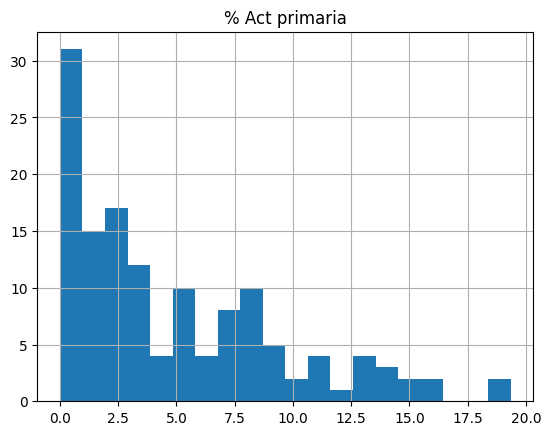

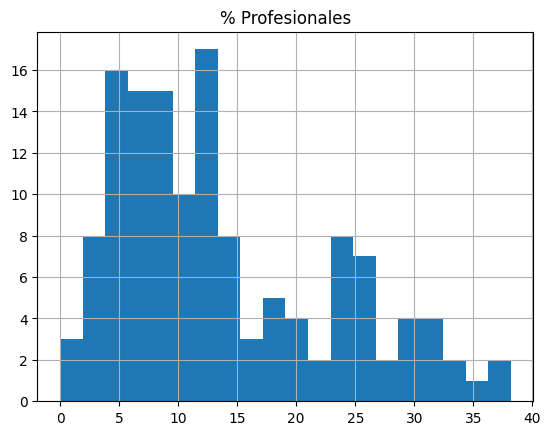

In [12]:
## 3.1 HISTOGRAMAS

gdf[['ptje_act_primaria']].hist(bins=20)
plt.title('% Act primaria')

gdf[['ptje_profesinales']].hist(bins=20)
plt.title('% Profesionales')

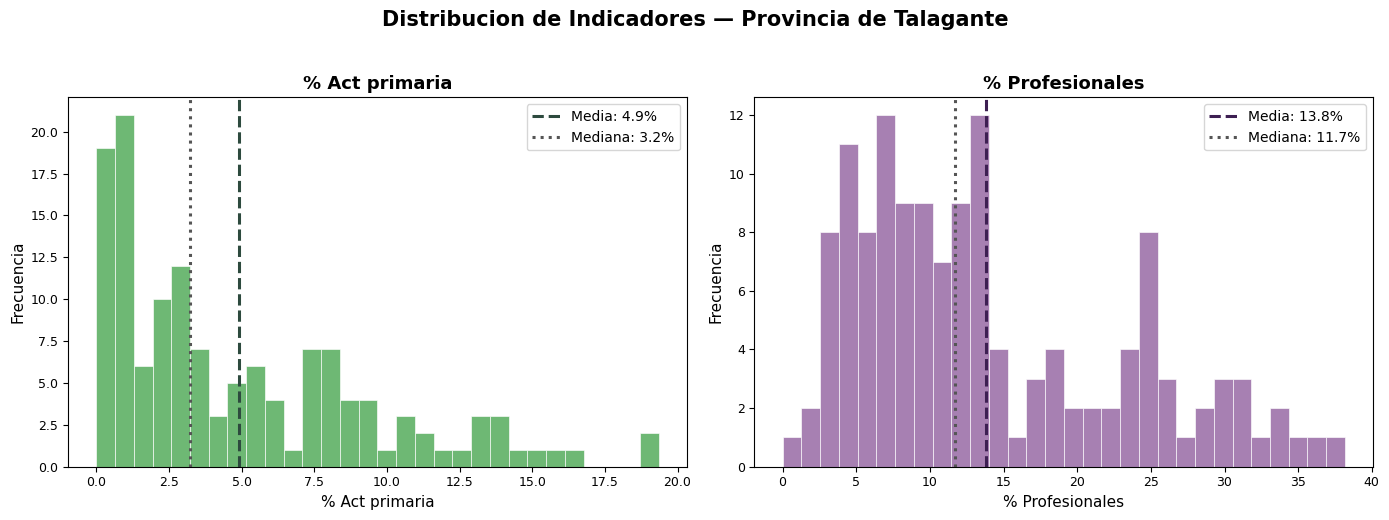

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Distribucion de Indicadores — Provincia de Talagante',
             fontsize=15, fontweight='bold', y=1.03)

vars_config = [
    ('ptje_act_primaria',    '#5aae61', '#2d4a3e', '% Act primaria'),
    ('ptje_profesinales', '#9b6fa8', '#3d1f52', '% Profesionales'),
]

for ax, (col, color, color_dark, label) in zip(axes, vars_config):
    datos = gdf[col].dropna()
    ax.hist(datos, bins=30, color=color, edgecolor='white', linewidth=0.5, alpha=0.88)
    ax.axvline(datos.mean(),   color=color_dark, ls='--', lw=2.2,
               label=f'Media: {datos.mean():.1f}%')
    ax.axvline(datos.median(), color='#555',     ls=':',  lw=2.2,
               label=f'Mediana: {datos.median():.1f}%')
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.legend(fontsize=10)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

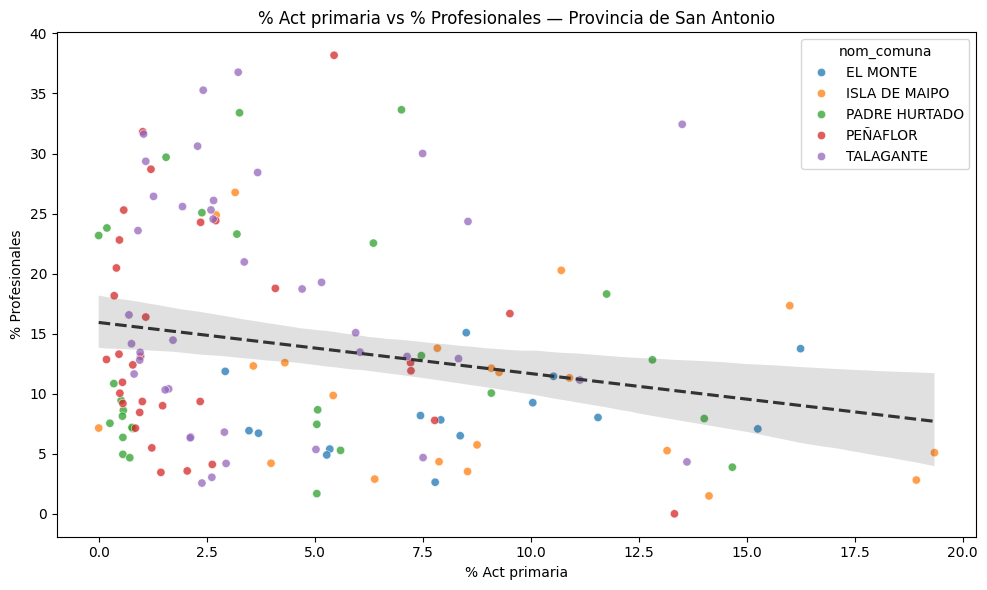

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=gdf, x='ptje_act_primaria', y='ptje_profesinales',
                hue='nom_comuna', alpha=0.75, ax=ax)

sns.regplot(data=gdf, x='ptje_act_primaria', y='ptje_profesinales',
            scatter=False, color='#333', line_kws={'ls': '--'}, ax=ax)

ax.set(xlabel='% Act primaria', ylabel='% Profesionales',
       title='% Act primaria vs % Profesionales — Provincia de San Antonio')
plt.tight_layout()
plt.show()

C:\Users\DIGEA\AppData\Local\Temp\ipykernel_9156\4257133502.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DIGEA\AppData\Local\Temp\ipykernel_9156\4257133502.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


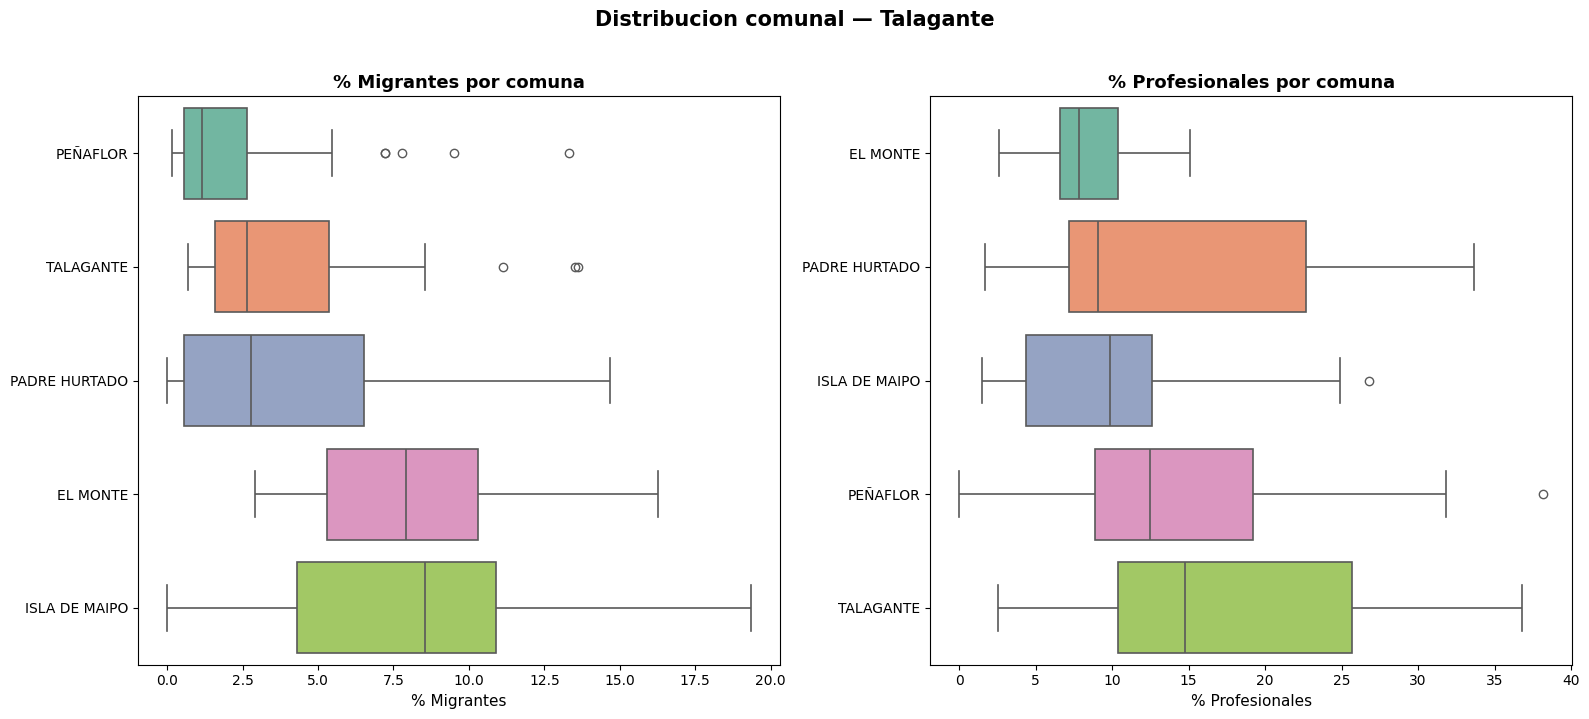

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle('Distribucion comunal — Talagante',
             fontsize=15, fontweight='bold', y=1.02)

n_comunas = gdf['nom_comuna'].nunique()
pal = sns.color_palette('Set2', n_colors=n_comunas)

for ax, col, label in [
    (axes[0], 'ptje_act_primaria',    '% Migrantes'),
    (axes[1], 'ptje_profesinales', '% Profesionales'),
]:
    orden = gdf.groupby('nom_comuna')[col].median().sort_values().index
    sns.boxplot(
        data=gdf, y='nom_comuna', x=col, order=orden,
        palette=pal,
        ax=ax, linewidth=1.2
    )
    ax.set_title(f'{label} por comuna', fontweight='bold', fontsize=13)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

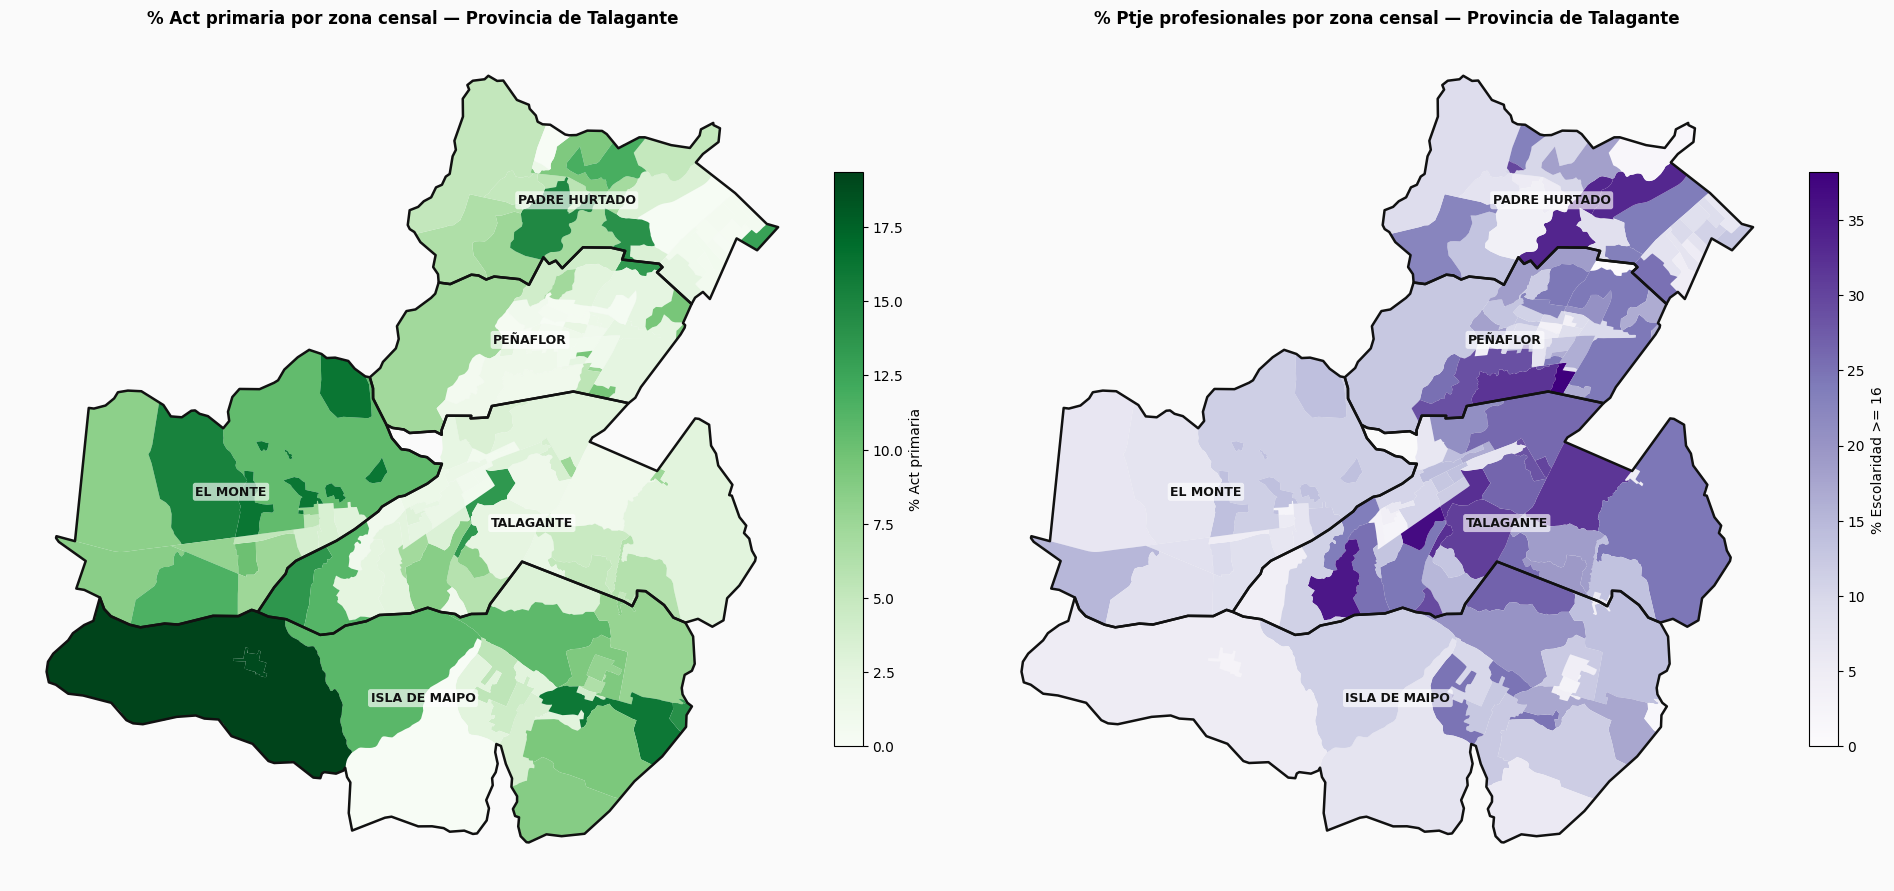

In [16]:
def plot_univariado(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['nom_comuna'],
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

plot_univariado(
    axes[0], gdf, gdf_comunas, gdf_centroides,
    'ptje_act_primaria', 'Greens',
    '% Act primaria por zona censal — Provincia de Talagante',
    '% Act primaria'
)
plot_univariado(
    axes[1], gdf, gdf_comunas, gdf_centroides,
    'ptje_profesinales', 'Purples',
    '% Ptje profesionales por zona censal — Provincia de Talagante',
    '% Escolaridad >= 16'
)

plt.tight_layout(pad=2)
plt.show()

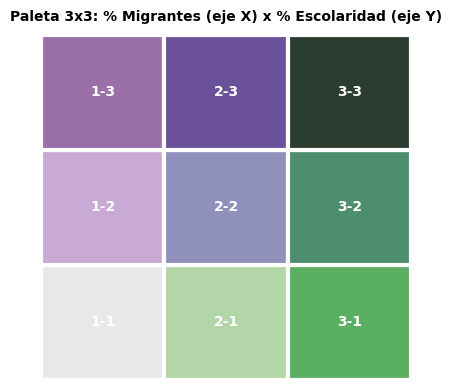

In [17]:
BIVARIATE_COLORS = {
    '1-1': '#e8e8e8',  # bajo-bajo   → neutro claro
    '2-1': '#b2d6a7',  # medio-bajo  → verde claro
    '3-1': '#5aae61',  # alto-bajo   → verde pleno
    '1-2': '#c8aad4',  # bajo-medio  → morado claro
    '2-2': '#9090bc',  # medio-medio → pizarra azul
    '3-2': '#4d8e6e',  # alto-medio  → verde-azul oscuro
    '1-3': '#9b6fa8',  # bajo-alto   → morado pleno
    '2-3': '#6b509a',  # medio-alto  → morado profundo
    '3-3': '#2b3d30',  # alto-alto   → verde muy oscuro
}

# Visualizar la paleta como grilla
fig_pal, ax_pal = plt.subplots(figsize=(4, 4))
for key, color in BIVARIATE_COLORS.items():
    i, j = map(int, key.split('-'))
    ax_pal.add_patch(plt.Rectangle(
        ((i - 1) / 3, (j - 1) / 3), 1/3, 1/3,
        transform=ax_pal.transAxes,
        facecolor=color, edgecolor='white', linewidth=3, clip_on=False
    ))
    ax_pal.text(
        (i - 0.5) / 3, (j - 0.5) / 3, key,
        ha='center', va='center', fontsize=10, color='white',
        fontweight='bold', transform=ax_pal.transAxes
    )
ax_pal.set_xlim(0, 1)
ax_pal.set_ylim(0, 1)
ax_pal.axis('off')
ax_pal.set_title('Paleta 3x3: % Migrantes (eje X) x % Escolaridad (eje Y)',
                 fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [18]:
cls_x = mapclassify.FisherJenks(gdf['ptje_act_primaria'].values,    k=3)
cls_y = mapclassify.FisherJenks(gdf['ptje_profesinales'].values, k=3)

gdf_bi = gdf.copy()
gdf_bi['class_x']  = cls_x.yb + 1 
gdf_bi['class_y']  = cls_y.yb + 1
gdf_bi['bi_class'] = gdf_bi['class_x'].astype(str) + '-' + gdf_bi['class_y'].astype(str)
gdf_bi['color']    = gdf_bi['bi_class'].map(BIVARIATE_COLORS)

print('Cortes Jenks — % Act primaria:')
print([round(b, 2) for b in cls_x.bins])
print('\nCortes Jenks — % Profesionales:')
print([round(b, 2) for b in cls_y.bins])
print(f'\nDistribucion de clases bivariadas:')
print(gdf_bi['bi_class'].value_counts().sort_index())

sin_color = gdf_bi[gdf_bi['color'].isna()]
if len(sin_color) == 0:
    print('\nTodas las zonas tienen color asignado')
else:
    print(f'\nAtencion: {len(sin_color)} zonas sin color: {sin_color["bi_class"].unique()}')

Cortes Jenks — % Act primaria:
[np.float64(4.31), np.float64(10.05), np.float64(19.35)]

Cortes Jenks — % Profesionales:
[np.float64(9.85), np.float64(20.47), np.float64(38.18)]

Distribucion de clases bivariadas:
bi_class
1-1    29
1-2    22
1-3    27
2-1    19
2-2    15
2-3     5
3-1    10
3-2     8
3-3     1
Name: count, dtype: int64

Todas las zonas tienen color asignado


C:\Users\DIGEA\anaconda3\envs\idg\Lib\site-packages\IPython\core\interactiveshell.py:3747: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


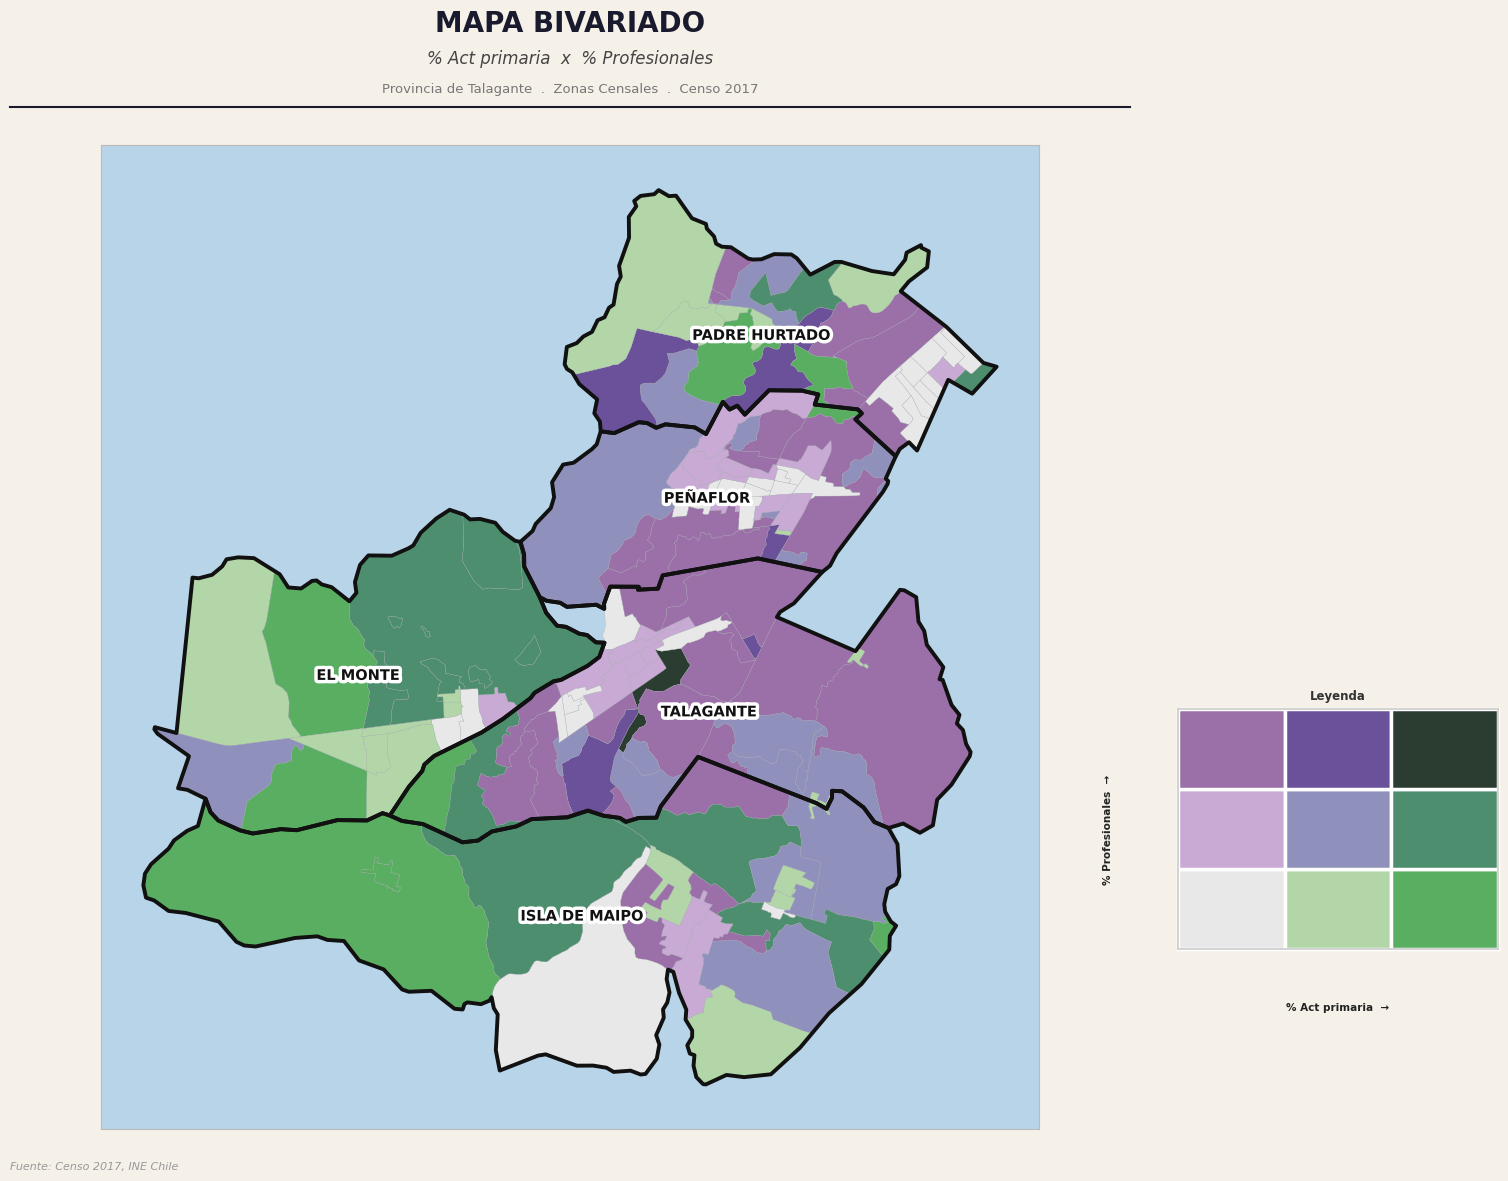

In [19]:
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

# ── Figura y layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa: izquierda 70%
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda: esquina derecha

# ── Mapa ─────────────────────────────────────────────────────────────────────
ax_map.set_facecolor('#b8d4e8')         # azul suave

# Zonas censales
gdf_bi.plot(
    color=gdf_bi['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

# Limites comunales: linea gruesa y oscura
gdf_comunas.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

# Etiquetas con stroke blanco 
for _, row in gdf_centroides.iterrows():
    txt = ax_map.annotate(
        row['nom_comuna'],
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

# Marco del mapa: borde fino gris
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

# ── Bloque de titulos (espacio figura) ──
fig.text(0.37, 0.965, 'MAPA BIVARIADO', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Act primaria  x  % Profesionales', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Talagante  .  Zonas Censales  .  Censo 2017',
         ha='center', fontsize=9.5, color='#777')

# Linea separadora bajo el titulo
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

# Fuente (pie de figura)
fig.text(0.02, 0.017, 'Fuente: Censo 2017, INE Chile',
         ha='left', fontsize=8, color='#999', style='italic')

# ── Leyenda bivariada ───
# Estilo del axes de leyenda: fondo blanco con borde gris
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Act primaria  →',
    ylab='% Profesionales  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()